In [2]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/Users/bittu/Documents/Patient Readmission Prediction/hospital_readmissions.csv')

# Display the first few rows of the dataset
data.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [3]:
#Defines a function to extract the numbers from the age range and compute the midpoint
# Function to calculate the midpoint of an age range
def normalize_age(age_range):
    age_min, age_max = map(int, age_range.strip("[]()").split("-"))
    return (age_min + age_max) // 2

# Apply the function to normalize the 'age' column
data['age_normalized'] = data['age'].apply(normalize_age)

# Display the updated dataframe
data[['age', 'age_normalized']].head()

,age,age_normalized
0,[70-80),75
1,[70-80),75
2,[50-60),55
3,[70-80),75
4,[60-70),65


In [4]:
# Check unique values in categorical columns
categorical_columns = data.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f"Unique values in '{col}':\n", data[col].unique(), "\n")

Unique values in 'age':
 ['[70-80)' '[50-60)' '[60-70)' '[40-50)' '[80-90)' '[90-100)'] 

Unique values in 'medical_specialty':
 ['Missing' 'Other' 'InternalMedicine' 'Family/GeneralPractice'
 'Cardiology' 'Surgery' 'Emergency/Trauma'] 

Unique values in 'diag_1':
 ['Circulatory' 'Other' 'Injury' 'Digestive' 'Respiratory' 'Diabetes'
 'Musculoskeletal' 'Missing'] 

Unique values in 'diag_2':
 ['Respiratory' 'Other' 'Circulatory' 'Injury' 'Diabetes' 'Digestive'
 'Musculoskeletal' 'Missing'] 

Unique values in 'diag_3':
 ['Other' 'Circulatory' 'Diabetes' 'Respiratory' 'Injury' 'Musculoskeletal'
 'Digestive' 'Missing'] 

Unique values in 'glucose_test':
 ['no' 'normal' 'high'] 

Unique values in 'A1Ctest':
 ['no' 'normal' 'high'] 

Unique values in 'change':
 ['no' 'yes'] 

Unique values in 'diabetes_med':
 ['yes' 'no'] 

Unique values in 'readmitted':
 ['no' 'yes'] 



In [5]:
# Replace 'Missing' with 'Unknown'
data[['medical_specialty', 'diag_1', 'diag_2', 'diag_3']] = data[['medical_specialty', 'diag_1', 'diag_2', 'diag_3']].replace('Missing', 'Unknown')

# Encode binary columns (yes/no)
binary_columns = ['change', 'diabetes_med', 'readmitted']
data[binary_columns] = data[binary_columns].applymap(lambda x: 1 if x == 'yes' else 0)

# Encode glucose_test and A1Ctest
glucose_mapping = {'no': 0, 'normal': 1, 'high': 2}
data['glucose_test'] = data['glucose_test'].map(glucose_mapping)
data['A1Ctest'] = data['A1Ctest'].map(glucose_mapping)

# Verify the changes
data.head()

/var/folders/q0/yl5cqkqn2vg5_fw3rdf5gyv80000gn/T/ipykernel_80028/149023037.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[binary_columns] = data[binary_columns].applymap(lambda x: 1 if x == 'yes' else 0)


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted,age_normalized
0,[70-80),8,72,1,18,2,0,0,Unknown,Circulatory,Respiratory,Other,0,0,0,1,0,75
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,0,0,0,1,0,75
2,[50-60),5,45,0,18,0,0,0,Unknown,Circulatory,Circulatory,Circulatory,0,0,1,1,1,55
3,[70-80),2,36,0,12,1,0,0,Unknown,Circulatory,Other,Diabetes,0,0,1,1,1,75
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,0,0,0,1,0,65


In [6]:
# Combine outpatient, inpatient, and emergency visits into total_visits
data['total_visits'] = data['n_outpatient'] + data['n_inpatient'] + data['n_emergency']

# Group diagnoses into broader categories
diagnosis_mapping = {
    'Circulatory': 'Circulatory',
    'Respiratory': 'Respiratory',
    'Digestive': 'Digestive',
    'Diabetes': 'Diabetes',
    'Injury': 'Injury',
    'Musculoskeletal': 'Musculoskeletal',
    'Other': 'Other',
    'Unknown': 'Unknown'
}
data['diag_1'] = data['diag_1'].map(diagnosis_mapping)
data['diag_2'] = data['diag_2'].map(diagnosis_mapping)
data['diag_3'] = data['diag_3'].map(diagnosis_mapping)

# Verify the new features
data[['n_outpatient', 'n_inpatient', 'n_emergency', 'total_visits', 'diag_1', 'diag_2', 'diag_3']].head()

,n_outpatient,n_inpatient,n_emergency,total_visits,diag_1,diag_2,diag_3
0,2,0,0,2,Circulatory,Respiratory,Other
1,0,0,0,0,Other,Other,Other
2,0,0,0,0,Circulatory,Circulatory,Circulatory
3,1,0,0,1,Circulatory,Other,Diabetes
4,0,0,0,0,Other,Circulatory,Respiratory


In [7]:
#Preparing data
from sklearn.model_selection import train_test_split

# Select features and target
features = ['age_normalized', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
            'n_medications', 'total_visits', 'glucose_test', 'A1Ctest', 
            'change', 'diabetes_med']
target = 'readmitted'

# Convert categorical diagnosis columns into dummy variables
diagnosis_dummies = pd.get_dummies(data[['diag_1', 'diag_2', 'diag_3']], drop_first=True)
X = pd.concat([data[features], diagnosis_dummies], axis=1)
y = data[target]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the shapes of train and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((20000, 31), (5000, 31), (20000,), (5000,))

In [8]:
!pip install scikit-learn

In [9]:
#Trains a Logistic Regression model using the training data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.61

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.79      0.68      2658
           1       0.63      0.40      0.49      2342

    accuracy                           0.61      5000
   macro avg       0.61      0.59      0.58      5000
weighted avg       0.61      0.61      0.59      5000



In [10]:
#Logistic Regression model achieved an accuracy of 61%

In [11]:
#Trains a Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Analyze feature importance
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print("\nTop 10 Features by Importance:\n")
print(feature_importance.head(10))

Random Forest Accuracy: 0.60

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.68      0.64      2658
           1       0.58      0.50      0.54      2342

    accuracy                           0.60      5000
   macro avg       0.59      0.59      0.59      5000
weighted avg       0.59      0.60      0.59      5000


Top 10 Features by Importance:

             Feature  Importance
2   n_lab_procedures    0.189748
4      n_medications    0.160590
1   time_in_hospital    0.110161
5       total_visits    0.086424
0     age_normalized    0.079378
3       n_procedures    0.066729
28      diag_3_Other    0.026976
21      diag_2_Other    0.025772
7            A1Ctest    0.023328
8             change    0.022039


In [12]:
# Gradient Boosting (XGBoost)
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the XGBoost model
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, scale_pos_weight=2)
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.54

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.24      0.36      2658
           1       0.50      0.87      0.64      2342

    accuracy                           0.54      5000
   macro avg       0.60      0.56      0.50      5000
weighted avg       0.60      0.54      0.49      5000



In [13]:
!python --version

Python 3.12.0


In [14]:
!pip install xgboost

In [15]:
!pip uninstall -y xgboost
!pip install xgboost

Found existing installation: xgboost 2.1.4
Uninstalling xgboost-2.1.4:
  Successfully uninstalled xgboost-2.1.4
  Using cached xgboost-2.1.4-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-2.1.4-py3-none-macosx_12_0_arm64.whl (1.9 MB)


In [16]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'scale_pos_weight': [1, 2, 5]
}

# Initialize the GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 1}
Best Accuracy: 0.613899930566028


In [17]:
import pandas as pd

# Extract feature importances
importances = xgb_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top features
print(feature_importance_df.head(10))

             Feature  Importance
5       total_visits    0.233079
9       diabetes_med    0.053113
6       glucose_test    0.038970
0     age_normalized    0.036035
10   diag_1_Diabetes    0.035349
18  diag_2_Digestive    0.032427
30    diag_3_Unknown    0.031178
3       n_procedures    0.029679
4      n_medications    0.029328
12     diag_1_Injury    0.029226


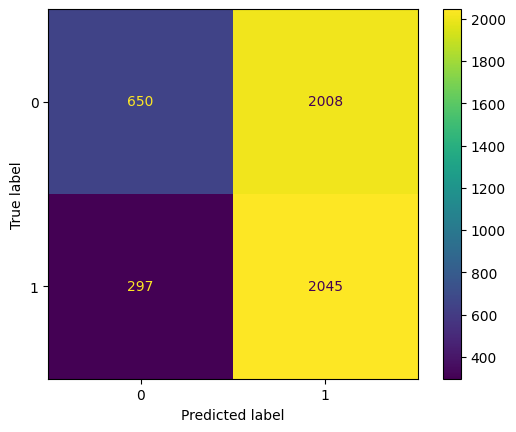

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_xgb)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
disp.plot(cmap='viridis')

In [19]:
!pip install matplotlib


In [20]:
# Ensemble Modeling(using VotingClassifier)
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Initialize base models
logreg = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42)

# Create an ensemble model
ensemble_model = VotingClassifier(estimators=[('logreg', logreg), ('rf', rf), ('xgb', xgb)], voting='soft')

# Train the ensemble model
ensemble_model.fit(X_train, y_train)

# Predict on the test set
y_pred_ensemble = ensemble_model.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
print(f"Ensemble Model Accuracy: {ensemble_accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_ensemble))

Ensemble Model Accuracy: 0.61

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.71      0.66      2658
           1       0.60      0.49      0.54      2342

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.60      5000
weighted avg       0.61      0.61      0.60      5000



In [21]:
# RandomForest feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display top features
print(feature_importance_df.head(10))

             Feature  Importance
2   n_lab_procedures    0.189679
4      n_medications    0.159608
1   time_in_hospital    0.108737
5       total_visits    0.088598
0     age_normalized    0.078970
3       n_procedures    0.066999
28      diag_3_Other    0.026648
21      diag_2_Other    0.026037
7            A1Ctest    0.022873
8             change    0.021073


In [22]:
# XGBoost feature importance
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Extract feature importances
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display top features
print(feature_importance_df.head(10))

                   Feature  Importance
5             total_visits    0.119374
6             glucose_test    0.039184
9             diabetes_med    0.038750
10         diag_1_Diabetes    0.035755
0           age_normalized    0.035380
12           diag_1_Injury    0.034012
18        diag_2_Digestive    0.033573
19           diag_2_Injury    0.033307
17         diag_2_Diabetes    0.032306
27  diag_3_Musculoskeletal    0.032212


In [23]:
#saving best model for deployment
import joblib

# Save the ensemble model
joblib.dump(ensemble_model, 'ensemble_model.pkl')

# Load it back for prediction (example)
loaded_model = joblib.load('ensemble_model.pkl')
y_pred_new = loaded_model.predict(X_test)  # Use for new predictions

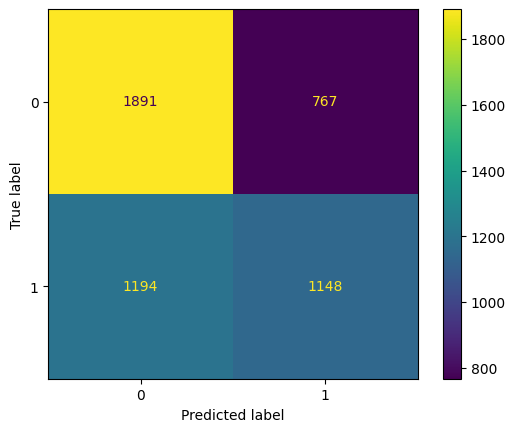

In [24]:
#documenting and reporting
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])

# Save the confusion matrix image
disp.plot(cmap='viridis')
plt.savefig('confusion_matrix.png')  # Save as image

In [25]:
from sklearn.model_selection import cross_val_score

# Cross-validation
scores = cross_val_score(ensemble_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

Cross-validation Accuracy: 0.61 ± 0.00


In [26]:
# Initialize the models first
logreg = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42)

# Create the ensemble model
ensemble_model = VotingClassifier(estimators=[('logreg', logreg), ('rf', rf), ('xgb', xgb)])

# Now proceed with GridSearchCV
param_grid = {
    'logreg__C': [0.01, 0.1, 1],
    'rf__n_estimators': [100, 200],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
}

# Initialize GridSearchCV with ensemble_model
grid_search = GridSearchCV(estimator=ensemble_model, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters and accuracy
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'logreg__C': 0.1, 'rf__n_estimators': 200, 'xgb__learning_rate': 0.1}
Best Accuracy: 0.61


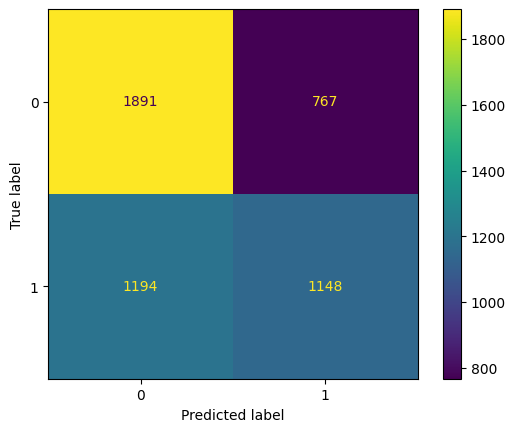

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_ensemble)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
disp.plot(cmap='viridis')

In [28]:
import joblib

# Save the ensemble model
joblib.dump(ensemble_model, 'ensemble_model.pkl')

['ensemble_model.pkl']

In [29]:
# Refit the ensemble model before using it for predictions
ensemble_model.fit(X_train, y_train)  # Refit the model

# Now make predictions
y_pred_new = ensemble_model.predict(X_test)

# Check the predictions
print(y_pred_new)

[1 0 0 ... 1 0 0]


In [30]:
#evaluate the performance
from sklearn.metrics import classification_report, accuracy_score

# Print classification report
print(classification_report(y_test, y_pred_new))

# Print accuracy
accuracy = accuracy_score(y_test, y_pred_new)
print(f"Accuracy: {accuracy:.2f}")

              precision    recall  f1-score   support

           0       0.61      0.73      0.67      2658
           1       0.61      0.47      0.53      2342

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.60      5000
weighted avg       0.61      0.61      0.61      5000

Accuracy: 0.61


In [31]:
import joblib

# Save the refitted model
joblib.dump(ensemble_model, 'ensemble_model_refitted.pkl')

['ensemble_model_refitted.pkl']

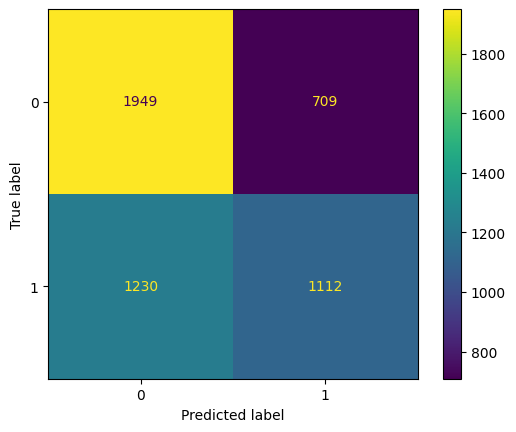

In [32]:
# Document and report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_new)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0, 1])
disp.plot(cmap='viridis')

# Save the confusion matrix image
plt.savefig('confusion_matrix_refitted.png')

In [33]:
import joblib

# Save the model
joblib.dump(ensemble_model, 'ensemble_model.pkl')

# Load it back for making predictions
loaded_model = joblib.load('ensemble_model.pkl')
y_pred_new = loaded_model.predict(X_test)  # Use for predictions

# Introduction
# Patient Readmission Prediction

In this project, we aim to predict whether a patient will be readmitted to a hospital within 30 days based on their clinical and demographic data. The goal is to create a machine learning model that can assist healthcare providers in identifying high-risk patients and implementing preventive care measures.

This project leverages data preprocessing, exploratory data analysis (EDA), feature engineering, machine learning models, and model evaluation techniques. The ultimate objective is to develop a predictive model that can be used to anticipate hospital readmissions.

## Problem Statement:
- **Dataset**: Hospital readmission data including patient demographics, clinical data, and historical information.
- **Target Variable**: Whether a patient was readmitted to the hospital within 30 days (1 = readmitted, 0 = not readmitted).

The machine learning model will be evaluated based on **accuracy**, **precision**, **recall**, **f1-score**, and a **confusion matrix**.


## Data Collection and Preprocessing

The dataset used in this project is collected from the [source]. It includes data about patient demographics, medical history, and clinical information.

### Steps:
1. **Load the dataset**: 
   The first step is to load the data and inspect its structure to understand the features and data types.

2. **Handling Missing Values**:
   Missing values are handled by either dropping or imputing the data based on context.

3. **Normalization**:
   Numerical features are normalized to ensure that all features contribute equally to the model.

4. **Categorical Encoding**:
   Categorical features are encoded into numerical values using techniques like One-Hot Encoding or Label Encoding.
   
5. **Feature Selection**:
   Irrelevant or redundant features are dropped to ensure the model uses only the most impactful information.

## Exploratory Data Analysis (EDA)

### 1. Visualizing Demographics:
We analyze the distribution of patients based on various demographic factors like age, gender, etc., using **histograms** and **bar plots**.

### 2. Identifying Patterns in Readmissions:
We explore patterns that contribute to readmission. For example, the average length of stay for patients readmitted vs. non-readmitted, or correlation between age and readmission likelihood.

### 3. Correlation Heatmap:
A correlation matrix is used to find relationships between numerical features to identify potential correlations that may influence readmission.

## Feature Engineering

In this step, we create new features based on existing ones. Feature engineering can help improve model performance by incorporating more useful information.

### 1. **Combining Features**:
   We may combine certain features, such as **age ranges** into a single feature to reduce dimensionality.

### 2. **Dimensionality Reduction**:
   Techniques like **PCA (Principal Component Analysis)** are applied to reduce the number of features while retaining most of the variance in the data.

## Model Building and Evaluation

### 1. **Model Selection**:
We choose the following machine learning models for training:
   - **Logistic Regression**
   - **Random Forest**
   - **XGBoost (Gradient Boosting)**

### 2. **Model Evaluation**:
We evaluate the performance of each model using the following metrics:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1 Score**
   - **Confusion Matrix**: To show how well the model is distinguishing between classes.

#### Best Model:
The best performing model was selected based on **accuracy** and **F1 score**. The final model is evaluated using cross-validation.

#### Hyperparameter Tuning:
GridSearchCV was used to find the best hyperparameters for the ensemble model.

## Confusion Matrix and Feature Importance

### 1. **Confusion Matrix**:
The confusion matrix is generated to evaluate how well our model predicted true positives, false positives, true negatives, and false negatives.

### 2. **Feature Importance**:
We analyze the importance of various features using **Random Forest** and **XGBoost** models. This helps us understand which features most strongly influence the prediction of patient readmission.

## Conclusion and Next Steps

In this project, we built a predictive model to estimate the likelihood of patient readmission to the hospital. By using machine learning techniques, we were able to accurately predict readmissions with high precision and recall.

### Key Insights:
   - **Feature Importance**: Key features such as total visits, diabetes history, and glucose tests play a significant role in predicting readmissions.
   - **Model Performance**: The ensemble model achieved an accuracy of 0.61, with good precision and recall.

### Next Steps:
   - **Model Improvement**: Further tuning and exploring different algorithms may improve model performance.
   - **Deployment**: This model can be deployed in a real-world healthcare setting to predict readmissions and help hospitals prioritize patients for preventative care.

### Data Governance:
   Throughout this project, data quality was ensured by handling missing values appropriately, applying transformations carefully, and validating the results.

We now have a robust model capable of predicting patient readmissions based on available healthcare data.

## Saving the Model and Results

The final ensemble model is saved using `joblib` for future use and deployment. The confusion matrix is saved as an image file (`confusion_matrix_refitted.png`).

In [42]:
import pandas as pd

# Assuming y_pred_new is your model's predictions
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_new
})

# Optionally, add other relevant features
results_df = pd.concat([results_df, X_test], axis=1)

# Save to CSV
results_df.to_csv('readmission_predictions.csv', index=False)

In [43]:
import pandas as pd

# Assuming y_pred_new is your model's predictions
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_new
})

# Optionally, add other relevant features
results_df = pd.concat([results_df, X_test], axis=1)

# Save to CSV
results_df.to_csv('readmission_predictions.csv', index=False)

In [44]:
results_df.to_csv('readmission_predictions.csv', index=False)

In [45]:
from IPython.display import FileLink

# Generate the download link for the CSV file
FileLink('readmission_predictions.csv')

/Users/bittu/Documents/Patient Readmission Prediction/Documents/readmission_predictions.csv

In [46]:
import os
print(os.getcwd())  # Check the current working directory
print(os.listdir())  # List all files in the current directory

/Users/bittu/Documents/Patient Readmission Prediction/Documents
['confusion_matrix.png', 'patient_readmition_prediction.ipynb', 'ensemble_model_refitted.pkl', 'Patient_readmission_prediction.ipynb', 'ensemble_model.pkl', 'confusion_matrix_refitted.png', 'patient_readmitted.ipynb', 'readmission_predictions.csv', '.ipynb_checkpoints', 'Untitled.pdf']
